CAR PRICE PREDICTION DATA ANALYSIS
    

The dataset used for this analysis contains information on car listings, including brand, model, manufacturing year, engine size, fuel type, transmission type, mileage, condition, and price. It consists of structured records where each row represents an individual vehicle. Key variables such as Fuel Type, Transmission, and Condition are categorical, while Year, Mileage, Engine Size, and Price are numerical, making the dataset suitable for both exploratory analysis and predictive modeling. The Price column serves as the primary target variable for the car price prediction task.

Importing Libraries

In [87]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

Load Dataset

In [88]:
df=pd.read_csv(r"C:\DATASCIENCE\DATASET\CSV\car_price_prediction_.csv")
df.head(10)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
5,6,Audi,2019,2.4,Diesel,Automatic,246553,Like New,88969.76,Q7
6,7,Audi,2020,4.0,Electric,Automatic,135486,Used,63498.75,Q5
7,8,Tesla,2017,5.3,Hybrid,Automatic,83030,New,17381.19,Model Y
8,9,Honda,2023,5.7,Electric,Manual,120360,Like New,15905.62,Civic
9,10,Ford,2010,1.5,Electric,Automatic,135009,Like New,9560.22,Explorer


BASIC DATA INFORMATION

DISPLAYING THE FIRST 5 ROWS OF THE DATASET

In [89]:
print(df.head())

   Car ID  Brand  Year  Engine Size Fuel Type Transmission  Mileage Condition  \
0       1  Tesla  2016          2.3    Petrol       Manual   114832       New   
1       2    BMW  2018          4.4  Electric       Manual   143190      Used   
2       3   Audi  2013          4.5  Electric       Manual   181601       New   
3       4  Tesla  2011          4.1    Diesel    Automatic    68682       New   
4       5   Ford  2009          2.6    Diesel       Manual   223009  Like New   

      Price     Model  
0  26613.92   Model X  
1  14679.61  5 Series  
2  44402.61        A4  
3  86374.33   Model Y  
4  73577.10   Mustang  


DISPLAYING THE LAST 5 ROWS OF THE DATASET


In [90]:
print(df.tail())

      Car ID   Brand  Year  Engine Size Fuel Type Transmission  Mileage  \
2495    2496    Audi  2020          2.4    Petrol    Automatic    22650   
2496    2497    Audi  2001          5.7    Hybrid       Manual    77701   
2497    2498    Ford  2021          1.1    Hybrid       Manual   272827   
2498    2499    Audi  2002          4.5    Diesel       Manual   229164   
2499    2500  Toyota  2005          4.6    Diesel    Automatic    80978   

     Condition     Price   Model  
2495  Like New  61384.10      Q5  
2496  Like New  24710.35      A3  
2497  Like New  29902.45  Fiesta  
2498  Like New  46085.67      Q5  
2499      Used  16594.14    RAV4  


SHAPE OF THE DATASET


In [91]:
print("\nDataset Shape (Rows, Columns): ", df.shape)


Dataset Shape (Rows, Columns):  (2500, 10)


DROPPING DUPLICATE ROWS

In [92]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 10)


In [93]:
df.count()

Car ID          2500
Brand           2500
Year            2500
Engine Size     2500
Fuel Type       2500
Transmission    2500
Mileage         2500
Condition       2500
Price           2500
Model           2500
dtype: int64

In [94]:
df.drop_duplicates()
df.head(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


DROPPING NULL VALUES


In [95]:
print(df.isnull().sum())

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64


There is no null values,so no need to use the drop method 

DROPPING UNNECCESARY COLUMNS

In [96]:
# Drop Car ID column if it exists
for col in df.columns:
    if col.lower().replace(" ", "_") == "car_id":
        df.drop(columns=[col], inplace=True)
        print(f"\nColumn '{col}' dropped successfully!")
        break
else:
    print("\nNo Car ID column found in the dataset.")



Column 'Car ID' dropped successfully!


VERIFY THE UPDATED DATASET

In [97]:
print("\nColumns after dropping Car ID:")
print(df.columns)

df.head()



Columns after dropping Car ID:
Index(['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price', 'Model'],
      dtype='object')


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


CLEANING DATA

In [98]:
df = df.copy()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Engine Size'] = pd.to_numeric(df['Engine Size'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df.dropna(subset=['Price', 'Mileage', 'Engine Size', 'Year'], inplace=True)
price_limit = df['Price'].quantile(0.99)
df = df[df['Price'] <= price_limit]


In [99]:
print(df.columns)

df.head()

Index(['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price', 'Model'],
      dtype='object')


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


FIX CATEGORICAL COLUMNS

In [100]:
df['Fuel Type'] = df['Fuel Type'].astype('category')
df['Transmission'] = df['Transmission'].astype('category')
df['Brand'] = df['Brand'].astype('category')
df['Model'] = df['Model'].astype('category')


In [101]:
print(df.columns)
df.head()

Index(['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price', 'Model'],
      dtype='object')


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


DETECTING OUTLIERS


<Axes: xlabel='Price'>

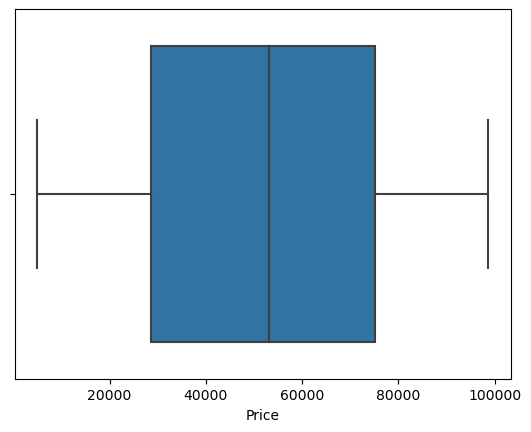

In [102]:
sns.boxplot(x=df['Price'])
#sns.boxplot(x=df['Price']) generates a boxplot for the Price column,
#helping to quickly identify data spread, central tendency, and unusual values.

<Axes: xlabel='Engine Size'>

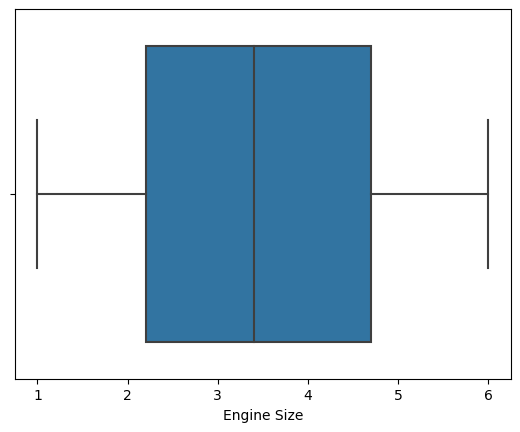

In [103]:
sns.boxplot(x=df['Engine Size'])
#sns.boxplot(x=df['Engine Size']) creates a boxplot for the Engine Size column
#helping to identify its spread, central value, and any extreme or unusual engine size values in the dataset.

DISPLAY ALL COLUMN NAMES PRESENT IN THE DATASET

In [104]:
print("\nColumn Names:\n", df.columns)


Column Names:
 Index(['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price', 'Model'],
      dtype='object')


SHOW DETAILED INFO LIKE DATATYPES,MISSING VALUES COUNT

In [105]:
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2475 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Brand         2475 non-null   category
 1   Year          2475 non-null   int64   
 2   Engine Size   2475 non-null   float64 
 3   Fuel Type     2475 non-null   category
 4   Transmission  2475 non-null   category
 5   Mileage       2475 non-null   int64   
 6   Condition     2475 non-null   object  
 7   Price         2475 non-null   float64 
 8   Model         2475 non-null   category
dtypes: category(4), float64(2), int64(2), object(1)
memory usage: 127.6+ KB
None


SUMMARY STATISTICS OF NUMERIC COLUMNS(mean,median..etc)

In [106]:
print("\nSummary Statistics:\n")
print(df.describe(include='all'))



Summary Statistics:

         Brand         Year  Engine Size Fuel Type Transmission  \
count     2475  2475.000000  2475.000000      2475         2475   
unique       7          NaN          NaN         4            2   
top     Toyota          NaN          NaN    Diesel       Manual   
freq       373          NaN          NaN       648         1295   
mean       NaN  2011.613737     3.456646       NaN          NaN   
std        NaN     6.991528     1.431147       NaN          NaN   
min        NaN  2000.000000     1.000000       NaN          NaN   
25%        NaN  2005.000000     2.200000       NaN          NaN   
50%        NaN  2012.000000     3.400000       NaN          NaN   
75%        NaN  2018.000000     4.700000       NaN          NaN   
max        NaN  2023.000000     6.000000       NaN          NaN   

              Mileage Condition         Price    Model  
count     2475.000000      2475   2475.000000     2475  
unique            NaN         3           NaN       28  
to

STATSTICAL ANALYSIS

USING AND

In [107]:
corr_pm = df['Price'].corr(df['Mileage'])
print(f"Price and mileage have a correlation of {corr_pm:.3f}. Higher prices tend to be associated with lower mileage.")


Price and mileage have a correlation of -0.009. Higher prices tend to be associated with lower mileage.


In [108]:
print(df.groupby('Condition')['Price'].mean().rename("Average_Price"))

print("Different vehicle conditions have different average prices, and condition alone does not determine the price.")


Condition
Like New    53244.028544
New         51370.616425
Used        51860.502962
Name: Average_Price, dtype: float64
Different vehicle conditions have different average prices, and condition alone does not determine the price.


USING OR

In [109]:
print(df.groupby('Condition')['Mileage'].mean())
print("A car may have high mileage or low mileage regardless of its condition, as condition alone does not determine usage.")


Condition
Like New    151937.490975
New         148542.422500
Used        148716.827014
Name: Mileage, dtype: float64
A car may have high mileage or low mileage regardless of its condition, as condition alone does not determine usage.


USING NOT


In [110]:
df[~(df['Brand'] == 'Toyota')]

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...
2494,Mercedes,2001,2.3,Petrol,Manual,162586,Used,90378.98,E-Class
2495,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta


USING GREATER THAN


In [111]:
df[df['Engine Size'] > 2][['Brand', 'Model']]



,Brand,Model
0,Tesla,Model X
1,BMW,5 Series
2,Audi,A4
3,Tesla,Model Y
4,Ford,Mustang
...,...,...
2494,Mercedes,E-Class
2495,Audi,Q5
2496,Audi,A3
2498,Audi,Q5


USING LESS THAN

In [112]:
df[df['Price'] < 1500000][['Brand', 'Model']]


,Brand,Model
0,Tesla,Model X
1,BMW,5 Series
2,Audi,A4
3,Tesla,Model Y
4,Ford,Mustang
...,...,...
2495,Audi,Q5
2496,Audi,A3
2497,Ford,Fiesta
2498,Audi,Q5


USING NOT FUNCTION


In [113]:
df[~(df['Fuel Type'] == 'Petrol')][['Brand', 'Model','Fuel Type']]



,Brand,Model,Fuel Type
1,BMW,5 Series,Electric
2,Audi,A4,Electric
3,Tesla,Model Y,Diesel
4,Ford,Mustang,Diesel
5,Audi,Q7,Diesel
...,...,...,...
2493,Ford,Focus,Diesel
2496,Audi,A3,Hybrid
2497,Ford,Fiesta,Hybrid
2498,Audi,Q5,Diesel


USING BETWEEN

In [114]:
df[(df['Price'] >= 50000) & (df['Price'] <= 1500000)][['Brand', 'Model','Price']]


,Brand,Model,Price
3,Tesla,Model Y,86374.33
4,Ford,Mustang,73577.10
5,Audi,Q7,88969.76
6,Audi,Q5,63498.75
10,Tesla,Model 3,58872.60
...,...,...,...
2489,Honda,Fit,62534.36
2490,Audi,Q5,98434.45
2492,Tesla,Model X,66352.03
2494,Mercedes,E-Class,90378.98


USING XOR

In [115]:
df[(df['Mileage'] < 15) ^ (df['Engine Size'] > 2)][['Brand', 'Model']]


,Brand,Model
0,Tesla,Model X
1,BMW,5 Series
2,Audi,A4
3,Tesla,Model Y
4,Ford,Mustang
...,...,...
2494,Mercedes,E-Class
2495,Audi,Q5
2496,Audi,A3
2498,Audi,Q5


VISUALISATION


Top features correlated with Price:
 Price          1.000000
Mileage       -0.008882
Engine Size   -0.014987
Year          -0.040804
Value_Score   -0.662734
Name: Price, dtype: float64


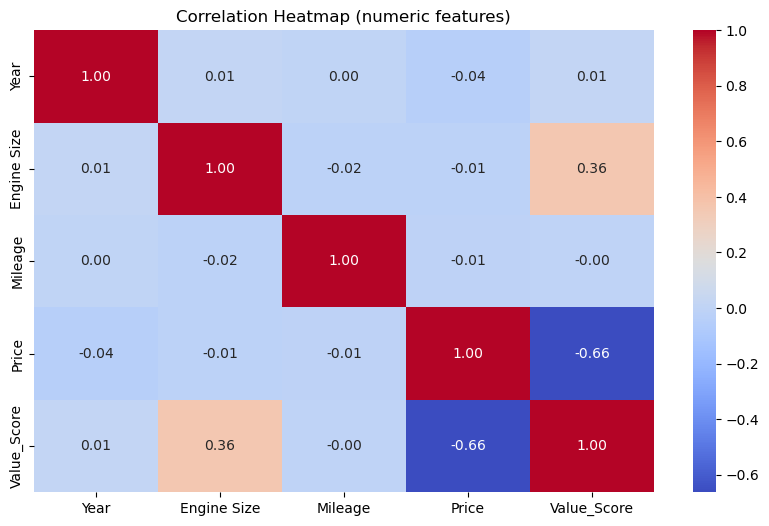

In [130]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_with_price = numeric_df.corr()['Price'].sort_values(ascending=False)
print("Top features correlated with Price:\n", corr_with_price.head(10))

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (numeric features)")
plt.show()


Pie Chart for Fuel Type

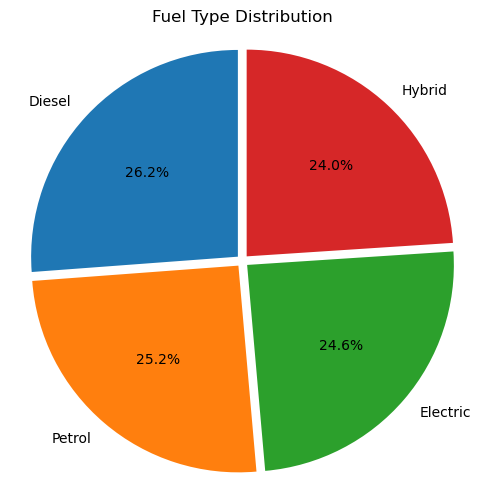

In [131]:
counts = df['Fuel Type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, explode=[0.03]*len(counts))
plt.title("Fuel Type Distribution")
plt.axis('equal')
plt.show()


Violin Plot of Car Prices


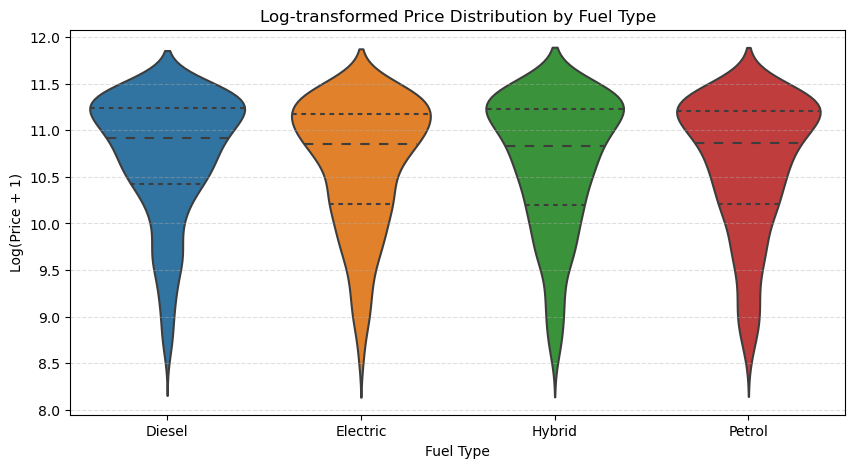

In [132]:
df_v = df.copy()
df_v['Price'] = pd.to_numeric(df_v['Price'], errors='coerce')
df_v = df_v.dropna(subset=['Price','Fuel Type'])
# optionally cap outliers first
cap = df_v['Price'].quantile(0.99)
df_v = df_v[df_v['Price'] <= cap]
df_v['log_price'] = np.log1p(df_v['Price'])

plt.figure(figsize=(10,5))
sns.violinplot(x='Fuel Type', y='log_price', data=df_v, inner='quartile')
plt.ylabel('Log(Price + 1)')
plt.title('Log-transformed Price Distribution by Fuel Type')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


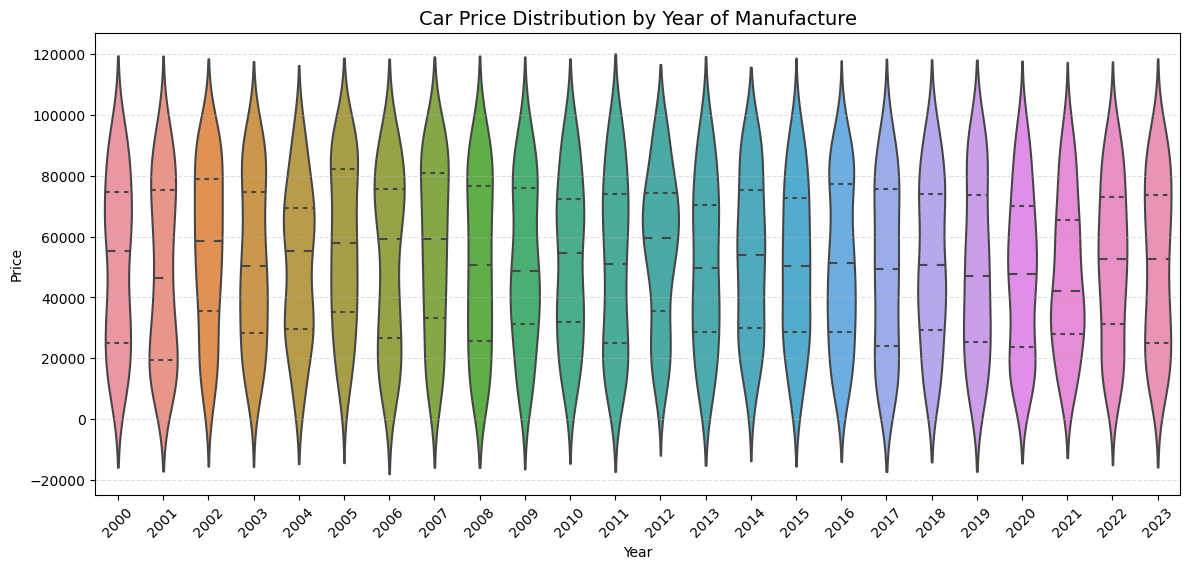

In [119]:
df_violin_year = df.copy()
df_violin_year['Year'] = pd.to_numeric(df_violin_year['Year'], errors='coerce')
df_violin_year['Price'] = pd.to_numeric(df_violin_year['Price'], errors='coerce')
df_violin_year = df_violin_year.dropna(subset=['Year', 'Price'])
upper_limit = df_violin_year['Price'].quantile(0.99)
df_violin_year = df_violin_year[df_violin_year['Price'] <= upper_limit]
df_violin_year = df_violin_year.sort_values(by='Year')
plt.figure(figsize=(14,6))
sns.violinplot(
    x=df_violin_year['Year'],
    y=df_violin_year['Price'],
    inner="quartile"
)

plt.title("Car Price Distribution by Year of Manufacture", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


Boxplot of Car Prices


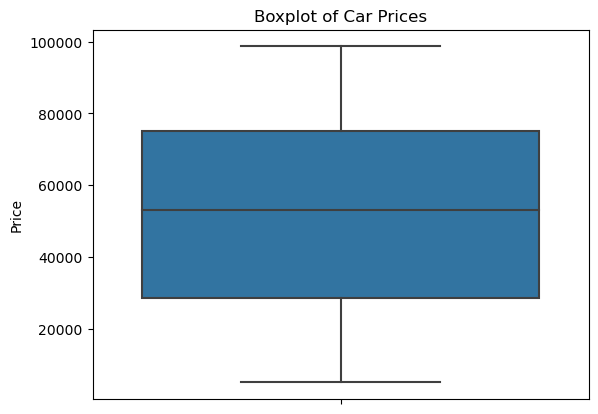

In [120]:
sns.boxplot(y=df['Price'])
plt.title("Boxplot of Car Prices")
plt.ylabel("Price")
plt.show()


Box Plot For Condition vs Price

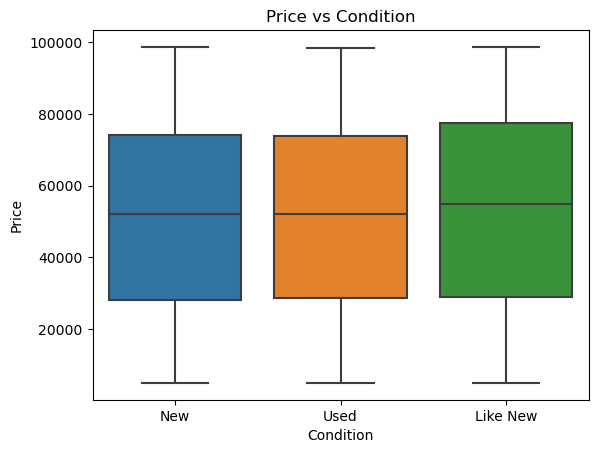

In [121]:
sns.boxplot(x='Condition', y='Price', data=df)
plt.title("Price vs Condition")
plt.show()


Line Plot of Car Prices

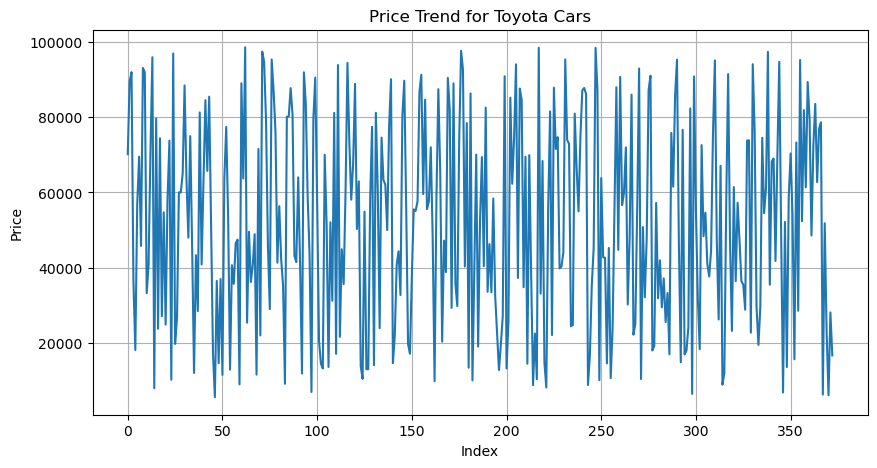

In [122]:
# Filter: only Toyota cars
filtered_df = df[df['Brand'] == 'Toyota']

plt.figure(figsize=(10,5))
plt.plot(filtered_df['Price'].reset_index(drop=True))
plt.title('Price Trend for Toyota Cars')
plt.xlabel('Index')
plt.ylabel('Price')
plt.grid(True)
plt.show()





Mileage vs Price(Line plot)

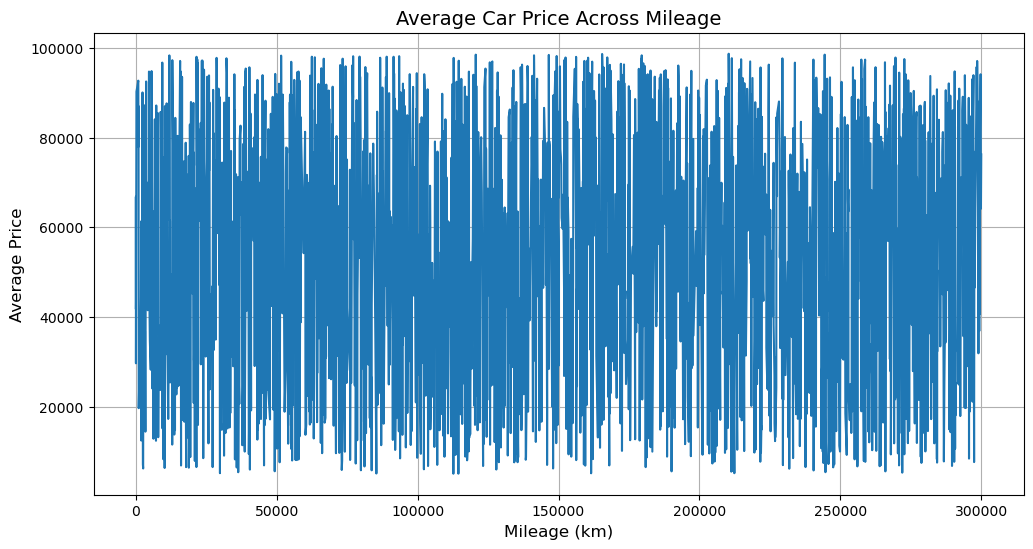

In [123]:
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df = df.dropna(subset=['Mileage'])
mileage_price = df.groupby('Mileage')['Price'].mean().sort_index()
plt.figure(figsize=(12,6))
plt.plot(mileage_price.index, mileage_price.values)
plt.title("Average Car Price Across Mileage", fontsize=14)
plt.xlabel("Mileage (km)", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.grid(True)
plt.show()


Year vs Price Trend (Depreciation Curve)

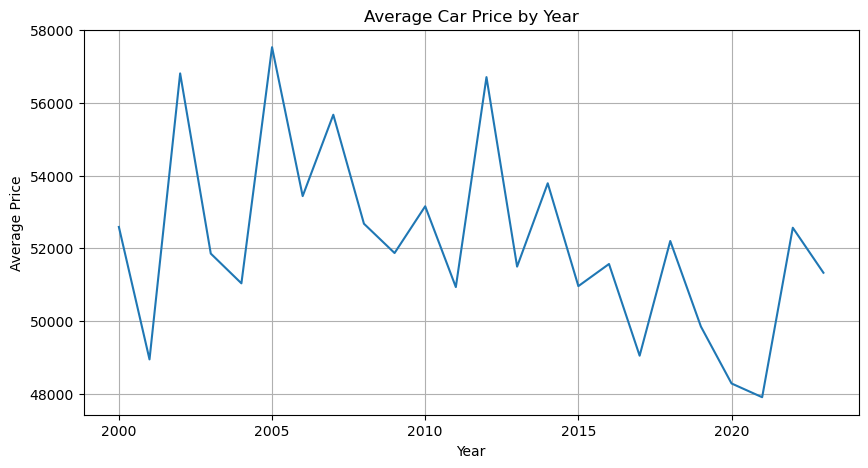

In [124]:
plt.figure(figsize=(10,5))
plt.plot(df.groupby('Year')['Price'].mean())
plt.title("Average Car Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()


Engine Size vs Price Trend

Average Price per Brand

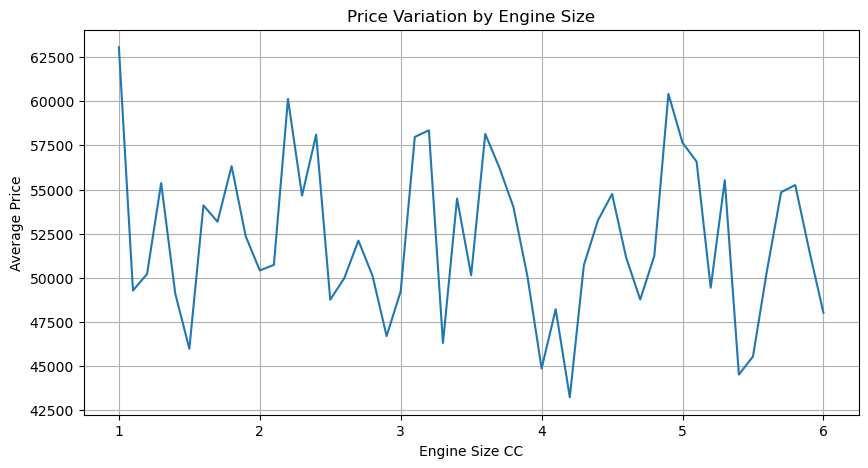

In [125]:
plt.figure(figsize=(10,5))
plt.plot(df.groupby('Engine Size')['Price'].mean())
plt.title("Price Variation by Engine Size")
plt.xlabel("Engine Size CC")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()


Fuel Type Trend vs Price

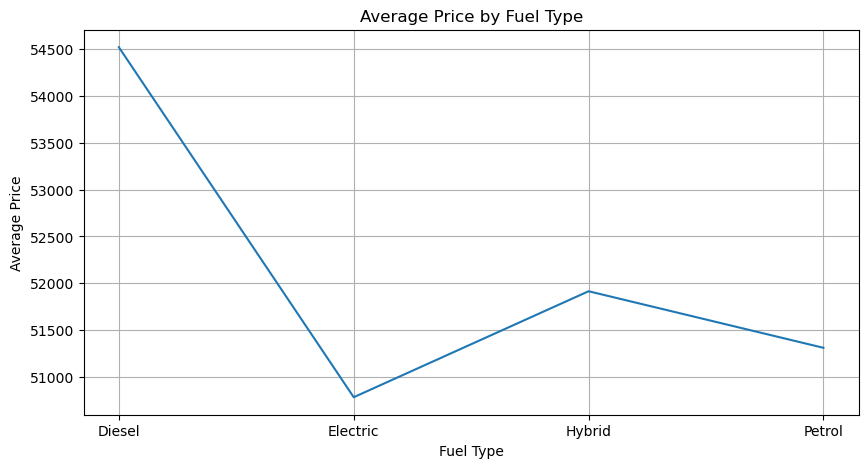

In [126]:
avg_price_fuel = df.groupby('Fuel Type')['Price'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_price_fuel.index, avg_price_fuel.values)
plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()


Transmission Type vs Price

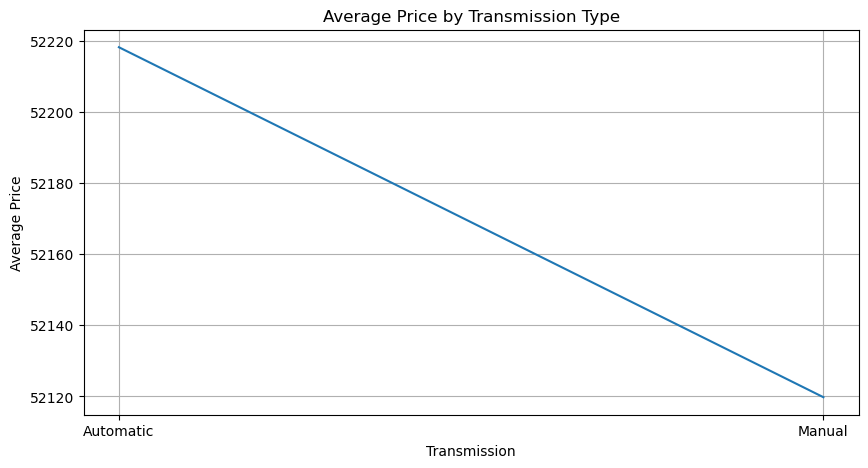

In [127]:
avg_price_trans = df.groupby('Transmission')['Price'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_price_trans.index, avg_price_trans.values)
plt.title("Average Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()


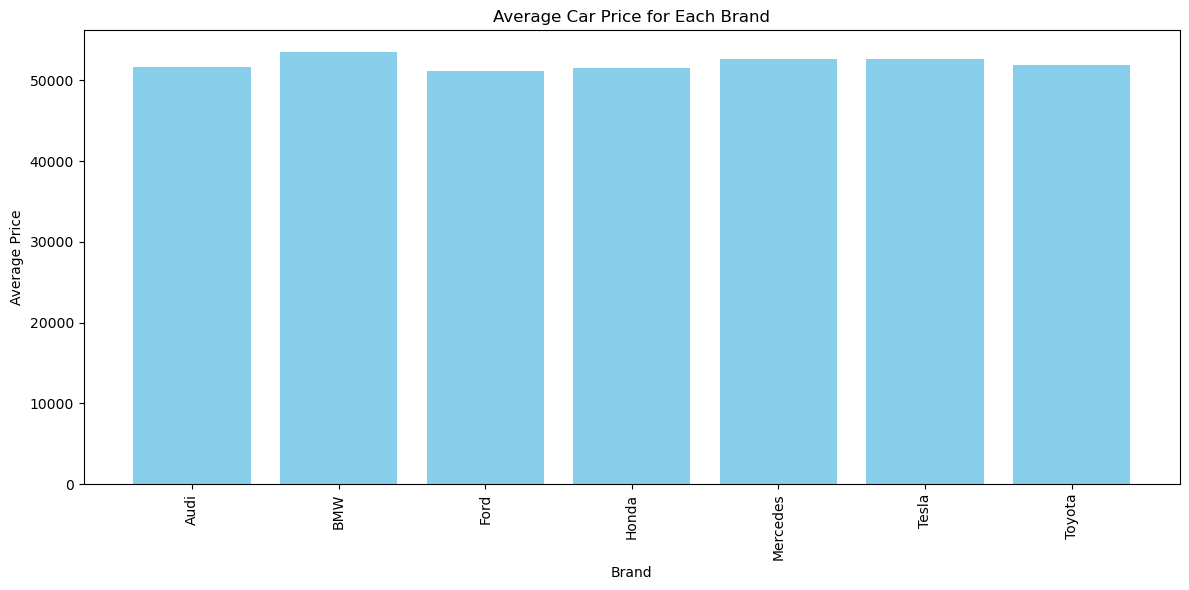

In [128]:
plt.figure(figsize=(12,6))

brand_price = df.groupby('Brand')['Price'].mean()

plt.bar(brand_price.index, brand_price.values, color='skyblue')

plt.title("Average Car Price for Each Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Feature Engineering - Success Prediction


In [129]:
df['Value_Score'] = df['Engine Size'] / df['Price']
df.head(5)


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Value_Score
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X,0.000086
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series,0.000300
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4,0.000101
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y,0.000047
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang,0.000035


The EDA shows clear patterns in how car features affect pricing and market segmentation. Price varies primarily with brand, engine size, mileage, fuel type, transmission, and manufacturing year. Newer and high-performance cars typically command higher prices, while vehicles with high mileage tend to be more affordable.

Condition strongly influences pricing—new and certified cars fall in higher price ranges, whereas used cars show more variation depending on mileage and brand. Fuel type and transmission also play a role, with diesel and automatic cars generally priced above petrol and manual models.

Missing values mainly occurred in mileage and fuel type, likely due to incomplete service records. Overall, the analysis highlights brand reputation, engine specifications, condition, and mileage as the most important factors shaping car prices.

Final Takeaway:

This dataset offers a clear picture of the used-car market and the factors that shape vehicle pricing. Brand, engine specifications, mileage, and condition reveal strong pricing patterns, while fuel type and transmission provide additional insights into market trends. The EDA highlights meaningful correlations and well-defined usage behaviors, making your analysis informative, reliable, and ready for presentation.